# 1 · Applicant EDA

Explore the observed cohort, segment repayment-difficulty rates and missingness. TARGET is a repayment-difficulty proxy, not a measured loss. These tables describe all applicants; predictive selection uses training rows only in the next notebook.

In [1]:
from pathlib import Path
import os
import sys
import json
import pandas as pd
from IPython.display import display, Image, Markdown

# The executor supplies these paths. Interactive runs default to local exports.
ROOT = Path(os.environ.get('HOME_CREDIT_PROJECT_ROOT', str(Path.cwd()))).resolve()
if not (ROOT / 'src' / 'analysis.py').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.analysis import ensure_analysis, load_features, eda_tables

INPUT = Path(os.environ.get('HOME_CREDIT_FEATURES', str(ROOT / 'exports' / 'applicant_features.csv')))
OUTPUT = Path(os.environ.get('HOME_CREDIT_ANALYSIS', str(ROOT / 'outputs' / 'analysis')))
STATUS = os.environ.get('HOME_CREDIT_DATA_STATUS', 'real')
LGD = float(os.environ.get('HOME_CREDIT_LGD', '0.45'))
SEED = int(os.environ.get('HOME_CREDIT_SEED', '42'))
manifest = ensure_analysis(INPUT, OUTPUT, data_status=STATUS, lgd=LGD, seed=SEED)
get_ipython().run_line_magic('matplotlib', 'inline')
display(Markdown(f'**Data status: {manifest["data_status"].upper()}**. '
    + ('Synthetic pipeline validation; no Home Credit conclusions.' if STATUS != 'real'
       else 'Computed from the supplied accepted-cohort export.')))


**Data status: REAL**. Computed from the supplied accepted-cohort export.

In [2]:
frame = load_features(INPUT)
eda = eda_tables(frame, OUTPUT)
display(eda['overall'])
display(eda['nulls'].sort_values('null_pct', ascending=False).head(20))

,applicants,bad_count,bad_rate,bad_rate_ci_low,bad_rate_ci_high,label_definition
0,307511,24825,0.080729,0.079771,0.081697,TARGET repayment difficulty


,feature,null_count,null_pct
83,cc_utilization_max,221475,72.021814
82,cc_utilization_mean,221475,72.021814
80,cc_max_dpd,220606,71.739222
85,cc_limit_sum_latest,220606,71.739222
84,cc_balance_sum_latest,220606,71.739222
81,cc_max_dpd_def,220606,71.739222
24,ext_source_1,173378,56.381073
61,bureau_credit_to_debt_ratio,122313,39.775163
12,occupation_type,96391,31.345545
26,ext_source_3,60965,19.825307


## Segment rates

Wilson 95% intervals show rate uncertainty. Small segments can have noisy rates; compare sample sizes before interpreting differences. This is descriptive exploration, not a decision rule fitted to the test outcomes.

In [3]:
segments = eda['segments']
display(segments.sort_values(['feature', 'bad_rate'], ascending=[True, False]).head(40))

,feature,level,applicants,bad_count,bad_rate,bad_rate_ci_low,bad_rate_ci_high
59,age_band,<=25,12233,1504,0.122946,1.172452e-01,0.128884
55,age_band,25-35,72429,7721,0.106601,1.043743e-01,0.108869
56,age_band,35-45,84261,7085,0.084084,8.222910e-02,0.085977
57,age_band,45-55,70190,4946,0.070466,6.859593e-02,0.072383
58,age_band,55-65,60522,3281,0.054212,5.243583e-02,0.056044
60,age_band,>65,7876,288,0.036567,3.264233e-02,0.040943
47,contract_type,Cash loans,278232,23221,0.083459,8.243719e-02,0.084493
48,contract_type,Revolving loans,29279,1604,0.054783,5.223470e-02,0.057449
11,education_type,Lower secondary,3816,417,0.109277,9.976812e-02,0.119571
12,education_type,Secondary / secondary special,218391,19524,0.089399,8.820986e-02,0.090603


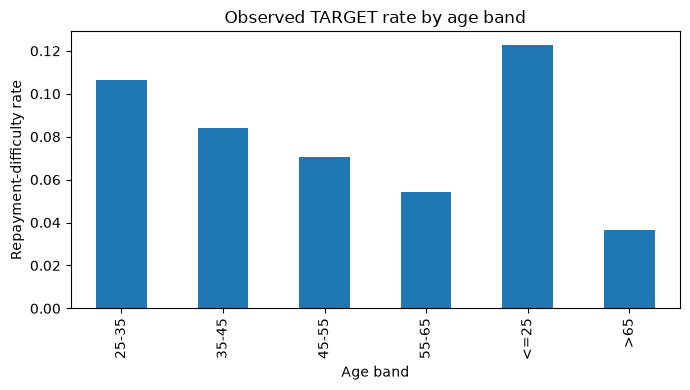

In [4]:
import matplotlib.pyplot as plt
age = segments[segments.feature == 'age_band']
if not age.empty:
    ax = age.plot.bar(x='level', y='bad_rate', legend=False, figsize=(7, 4), title='Observed TARGET rate by age band')
    ax.set_ylabel('Repayment-difficulty rate')
    ax.set_xlabel('Age band')
    plt.tight_layout()
    plt.show()

## Scope

Only application_train outcomes are analyzed. Raw data retain test-population historical records; SQL filters intermediate features to the observed training applicants. Missing numeric history measurements remain missing, while genuinely absent history counts are zero. Full raw null/sentinel/orphan checks are in the separate DQ exports.